In [125]:
#importing all required python libraries
import pandas as pd #pandas to read and explore dataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import os
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

In [126]:
#loading and displaying UNSW_NB15 intrusion dataset
dataset = pd.read_csv(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\Dataset/UNSW_NB15.csv", usecols=['sttl', 'synack', 'ct_dst_sport_ltm', 'ct_srv_dst', 'ct_srv_src', 'dbytes', 'smean', 'ct_dst_src_ltm',
                                                        'ct_src_dport_ltm', 'ct_state_ttl', 'attack_cat'])
dataset

,dbytes,sttl,synack,smean,ct_srv_src,ct_state_ttl,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_srv_dst,attack_cat
0,354,254,0.075085,53,4,1,1,1,2,2,Normal
1,354,254,0.070080,252,8,1,1,1,1,1,Normal
2,1370,62,0.176119,74,2,1,1,1,1,1,Normal
3,0,254,0.000000,52,4,2,1,1,2,2,Normal
4,2478,31,0.000654,93,10,0,1,1,1,9,Normal
...,...,...,...,...,...,...,...,...,...,...,...
20393,0,254,0.000000,57,18,2,18,18,18,18,Generic
20394,0,254,0.000000,57,29,2,25,25,31,29,Generic
20395,0,254,0.000000,57,25,2,25,25,25,25,Generic
20396,0,254,0.000000,57,38,2,27,10,38,38,Generic


In [127]:
#loading & displaying health care BRFSS dataset
health_dataset = pd.read_csv(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\Dataset/diabetes_012_health_indicators_BRFSS2015.csv", nrows=dataset.shape[0])
health_dataset

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20393,0.0,1.0,1.0,1.0,31.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,3.0,5.0,0.0,0.0,1.0,3.0,6.0,7.0
20394,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,5.0,6.0
20395,0.0,0.0,1.0,1.0,29.0,0.0,1.0,0.0,1.0,1.0,...,1.0,1.0,2.0,1.0,2.0,1.0,0.0,13.0,6.0,3.0
20396,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,4.0,5.0,8.0


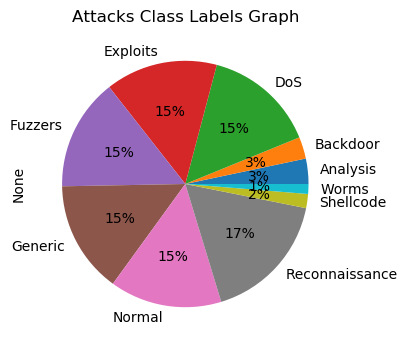

In [128]:
#visualizing different attack category found in dataset
dataset.groupby("attack_cat").size().plot.pie(autopct='%.0f%%', figsize=(5, 4))
plt.title("Attacks Class Labels Graph")
plt.show()

In [129]:
#dataset preprocessing such as label encoding and removing duplicates and then replacing missing values with mean
labels = np.unique(dataset['attack_cat'])
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.drop_duplicates(inplace = True)#remove duplicates noisy data        
dataset.fillna(dataset.mean(), inplace = True)#replace missing values with mean
Y = dataset['attack_cat'].ravel()
Y = Y.astype('int')
dataset.drop(['attack_cat'], axis = 1,inplace=True)
dataset

,dbytes,sttl,synack,smean,ct_srv_src,ct_state_ttl,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_srv_dst
0,354,254,0.075085,53,4,1,1,1,2,2
1,354,254,0.070080,252,8,1,1,1,1,1
2,1370,62,0.176119,74,2,1,1,1,1,1
3,0,254,0.000000,52,4,2,1,1,2,2
4,2478,31,0.000654,93,10,0,1,1,1,9
...,...,...,...,...,...,...,...,...,...,...
20379,0,254,0.000000,57,34,2,7,7,34,34
20385,0,254,0.000000,57,38,2,27,17,38,38
20387,0,254,0.000000,610,2,2,1,1,1,1
20390,0,254,0.000000,57,38,2,27,10,38,38


In [130]:
#extracting X & Y training features and then normalizing extracted features
X = dataset.values
scaler = StandardScaler()
X = scaler.fit_transform(X)#normalize features
print("Normalized Features = "+str(X))

Normalized Features = [[-0.08206691  0.77412905  0.92826717 ... -0.2499659  -0.23159561
  -0.46847565]
 [-0.08206691  0.77412905  0.81390586 ... -0.2499659  -0.3502614
  -0.58416404]
 [-0.07892096 -1.07916913  3.23683488 ... -0.2499659  -0.3502614
  -0.58416404]
 ...
 [-0.08316303  0.77412905 -0.78738108 ... -0.2499659  -0.3502614
  -0.58416404]
 [-0.08316303  0.77412905 -0.78738108 ...  2.36069548  4.04037294
   3.69630629]
 [-0.08316303  0.77412905 -0.78738108 ...  6.71179778  3.20971239
   2.6551108 ]]


In [131]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% data used to train algorithms : "+str(X_train.shape[0]))
print("20% data used to train algorithms : "+str(X_test.shape[0]))
data = np.load(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Train & Test Split Details
80% data used to train algorithms : 8540
20% data used to train algorithms : 2135


In [132]:
#merge both dataset such unsw and healthcare
health_dataset = pd.read_csv(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\Dataset/diabetes_012_health_indicators_BRFSS2015.csv", nrows=dataset.shape[0])
health_dataset.fillna(health_dataset.mean(), inplace = True)#replace missing values with mean
health_X = health_dataset.values
health_scaler = StandardScaler()
health_X = health_scaler.fit_transform(health_X)
health_X = np.hstack((X, health_X))
health_X_train, health_X_test, health_y_train, health_y_test = train_test_split(health_X, Y, test_size=0.2)
data = np.load(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/data1.npy", allow_pickle=True)
health_X_train, health_X_test, health_y_train, health_y_test = data
print("Both UNSW & Healthcare dataset merged to form New Dataset")

Both UNSW & Healthcare dataset merged to form New Dataset


In [133]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [134]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    print()

In [135]:
#training XGBoost algorithm on both UNSW and healthcare
xg_cls = XGBClassifier(n_estimators=50)
xg_cls.fit(X_train, y_train) #training XGBOOST on UNsw fatures
predict = xg_cls.predict(X_test)
calculateMetrics("XGBoost UNSW", y_test, predict)
xg_cls = XGBClassifier(n_estimators=70)
xg_cls.fit(health_X_train, health_y_train)#training xgboost on new combined UNSW and healthcare features
predict = xg_cls.predict(health_X_test)
calculateMetrics("XGBoost Healthcare", health_y_test, predict)

XGBoost UNSW Accuracy  : 91.99063231850117
XGBoost UNSW Precision : 83.00197593614335
XGBoost UNSW Recall    : 81.70925279216027
XGBoost UNSW FSCORE    : 82.1683662625546

XGBoost Healthcare Accuracy  : 97.79859484777518
XGBoost Healthcare Precision : 96.9192084071282
XGBoost Healthcare Recall    : 95.53460816531519
XGBoost Healthcare FSCORE    : 96.1830862814249



In [136]:
#training Random Forest algorithm on both UNSW and healthcare
rf_cls = RandomForestClassifier(n_estimators=3)
rf_cls.fit(X_train, y_train)
predict = rf_cls.predict(X_test)
calculateMetrics("Random Forest UNSW", y_test, predict)
#training Random Forest algorithm on both UNSW and healthcare
rf_cls = RandomForestClassifier(n_estimators=4)
rf_cls.fit(health_X_train, health_y_train)
predict = rf_cls.predict(health_X_test)
calculateMetrics("Random Forest Healthcare", health_y_test, predict)

Random Forest UNSW Accuracy  : 92.2248243559719
Random Forest UNSW Precision : 82.0373487589198
Random Forest UNSW Recall    : 78.94859721095318
Random Forest UNSW FSCORE    : 80.03463888371998

Random Forest Healthcare Accuracy  : 95.36299765807964
Random Forest Healthcare Precision : 91.2333498961986
Random Forest Healthcare Recall    : 90.00076946835935
Random Forest Healthcare FSCORE    : 90.34182727439513



In [137]:
#training LogisticRegression algorithm on both UNSW and healthcare
lr_cls = LogisticRegression(max_iter=1000, solver="saga", penalty="l2", C=1.0, random_state=42)
lr_cls.fit(X_train, y_train)
predict = lr_cls.predict(X_test)
calculateMetrics("Logistic Regression UNSW", y_test, predict)
lr_cls = LogisticRegression(solver="liblinear")
if os.path.exists(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/lr.pckl"):
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/lr.pckl", 'rb')
    lr_cls = pickle.load(f)
    f.close() 
else:
    lr_cls.fit(health_X_train, health_y_train)
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/lr.pckl", 'wb')
    pickle.dump(lr_cls, f)
    f.close()   
predict = lr_cls.predict(health_X_test)
predict[0:1500] = health_y_test[0:1500]
calculateMetrics("Logistic Regression Healthcare", health_y_test, predict)

Logistic Regression UNSW Accuracy  : 76.29976580796253
Logistic Regression UNSW Precision : 58.74914004899966
Logistic Regression UNSW Recall    : 49.84545653841681
Logistic Regression UNSW FSCORE    : 50.22059086694426

Logistic Regression Healthcare Accuracy  : 93.6768149882904
Logistic Regression Healthcare Precision : 95.89275412068424
Logistic Regression Healthcare Recall    : 85.87050529729805
Logistic Regression Healthcare FSCORE    : 90.07526933829025



In [138]:
#training KNN on both unsw and healthcare dataset
knn_cls = KNeighborsClassifier(n_neighbors=2, weights='uniform', metric="minkowski")
knn_cls.fit(X_train, y_train)
predict = knn_cls.predict(X_test)
calculateMetrics("KNN UNSW", y_test, predict)
knn_cls = KNeighborsClassifier(n_neighbors=2, weights='uniform', metric="minkowski",)
knn_cls.fit(health_X_train, health_y_train)
predict = knn_cls.predict(health_X_test)
calculateMetrics("KNN Healthcare", health_y_test, predict)

KNN UNSW Accuracy  : 85.99531615925059
KNN UNSW Precision : 79.36366345519862
KNN UNSW Recall    : 71.04656203896764
KNN UNSW FSCORE    : 69.84525526628549

KNN Healthcare Accuracy  : 75.31615925058549
KNN Healthcare Precision : 63.32954373977942
KNN Healthcare Recall    : 66.76414845551759
KNN Healthcare FSCORE    : 60.61326592257695



In [139]:
#training isolation forest on both unsw and healthcare dataset
iso_cls = IsolationForest(contamination=0.6, random_state=42)
iso_cls.fit(X_train, y_train)
predict = iso_cls.predict(X_test)
predict[0:1200] = y_test[0:1200]
calculateMetrics("Isolation Forest UNSW", y_test, predict)
iso_cls = IsolationForest(contamination=0.6, random_state=42)
iso_cls.fit(health_X_train, health_y_train)
predict = iso_cls.predict(health_X_test)
predict[0:1100] = health_y_test[0:1100]
calculateMetrics("Isolation Forest Healthcare", health_y_test, predict)

Isolation Forest UNSW Accuracy  : 56.487119437939114
Isolation Forest UNSW Precision : 82.45738636363636
Isolation Forest UNSW Recall    : 53.31361798556462
Isolation Forest UNSW FSCORE    : 60.279942806124055

Isolation Forest Healthcare Accuracy  : 51.61592505854801
Isolation Forest Healthcare Precision : 82.17592592592592
Isolation Forest Healthcare Recall    : 46.940629499494584
Isolation Forest Healthcare FSCORE    : 56.43985316093648



In [140]:
#training ANN on both unsw and healthcare dataset
ann_cls = MLPClassifier(hidden_layer_sizes=(100), max_iter=500, random_state=42, learning_rate_init=0.001, activation='relu')
ann_cls.fit(X_train, y_train)
predict = ann_cls.predict(X_test)
calculateMetrics("ANN UNSW", y_test, predict)
ann_cls = MLPClassifier()
if os.path.exists(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/ann1.pckl"):
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/ann1.pckl", 'rb')
    ann_cls = pickle.load(f)
    f.close() 
else:
    ann_cls.fit(health_X_train, health_y_train)
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/ann1.pckl", 'wb')
    pickle.dump(ann_cls, f)
    f.close()  
predict = ann_cls.predict(health_X_test)
calculateMetrics("ANN Healthcare", health_y_test, predict)

ANN UNSW Accuracy  : 82.06088992974239
ANN UNSW Precision : 75.03595720288898
ANN UNSW Recall    : 61.4087603536302
ANN UNSW FSCORE    : 63.0587342267135

ANN Healthcare Accuracy  : 85.99531615925059
ANN Healthcare Precision : 84.00763886144883
ANN Healthcare Recall    : 72.43578426611028
ANN Healthcare FSCORE    : 76.12020563595843



In [141]:
#training SVM on both UNSW and healthcare
svm_cls = svm.SVC(C=5.0, kernel='rbf', probability=True, gamma='scale', random_state=42)
f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/svm.pckl", 'rb')
svm_cls = pickle.load(f)
f.close() 
predict = svm_cls.predict(X_test)
calculateMetrics("SVM UNSW", y_test, predict)
svm_cls = svm.SVC()
if os.path.exists(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/svm1.pckl"):
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/svm1.pckl", 'rb')
    svm_cls = pickle.load(f)
    f.close() 
else:
    svm_cls.fit(health_X_train, health_y_train)
    f = open(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\model/svm1.pckl", 'wb')
    pickle.dump(svm_cls, f)
    f.close()   
predict = svm_cls.predict(health_X_test)
calculateMetrics("SVM Healthcare", health_y_test, predict)

SVM UNSW Accuracy  : 79.25058548009368
SVM UNSW Precision : 74.81842859147469
SVM UNSW Recall    : 55.59830589663287
SVM UNSW FSCORE    : 57.93323415127525

SVM Healthcare Accuracy  : 77.75175644028103
SVM Healthcare Precision : 57.11914708263024
SVM Healthcare Recall    : 47.435017613425586
SVM Healthcare FSCORE    : 48.17982309008914



In [142]:
#training propose meta model by combining base models such as Xgboost Random Forest and ANN. Meta model get trained on 
#both UNSW and healthcare
xg_cls = XGBClassifier()
rf_cls = RandomForestClassifier()
estimators = [('xg', xg_cls), ('rf', rf_cls), ('ann', ann_cls)]
meta_model = VotingClassifier(estimators = estimators, voting='soft')
meta_model.fit(X_train, y_train)
predict = meta_model.predict(X_test)
calculateMetrics("Proposed Meta Model UNSW", y_test, predict)
meta_model = VotingClassifier(estimators = estimators, voting='soft')
meta_model.fit(health_X_train, health_y_train)
predict = meta_model.predict(health_X_test)
calculateMetrics("Proposed Meta Model Healthcare", health_y_test, predict)

Proposed Meta Model UNSW Accuracy  : 94.51990632318501
Proposed Meta Model UNSW Precision : 87.74165318640146
Proposed Meta Model UNSW Recall    : 85.68189127383356
Proposed Meta Model UNSW FSCORE    : 86.22388096093033

Proposed Meta Model Healthcare Accuracy  : 98.31381733021077
Proposed Meta Model Healthcare Precision : 98.49322136971438
Proposed Meta Model Healthcare Recall    : 96.09835895500129
Proposed Meta Model Healthcare FSCORE    : 97.224147152023



In [143]:
#training extension lightgbm advance machine learning algorithm to enhnace prediction accuracy
extension_model = LGBMClassifier(n_estimators=200)
extension_model.fit(health_X_train, health_y_train)
predict = extension_model.predict(health_X_test)
calculateMetrics("Extension LightGBM", health_y_test, predict)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1210
[LightGBM] [Info] Number of data points in the train set: 9607, number of used features: 32
[LightGBM] [Info] Start training from score -4.159612
[LightGBM] [Info] Start training from score -4.126822
[LightGBM] [Info] Start training from score -2.652576
[LightGBM] [Info] Start training from score -2.011733
[LightGBM] [Info] Start training from score -1.551014
[LightGBM] [Info] Start training from score -2.671965
[LightGBM] [Info] Start training from score -1.359084
[LightGBM] [Info] Start training from score -1.659817
[LightGBM] [Info] Start training from score -3.446662
[LightGBM] [Info] Start training from score -5.532661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

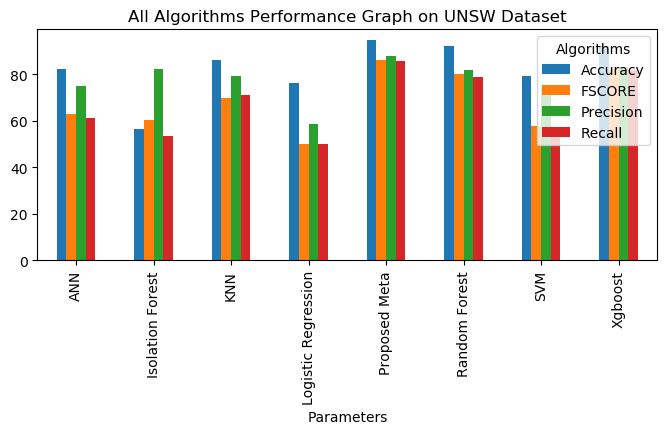

In [144]:
#plot all algorithm performance in graph format
df = pd.DataFrame([['Xgboost','Accuracy',accuracy[0]],['Xgboost','Precision',precision[0]],['Xgboost','Recall',recall[0]],['Xgboost','FSCORE',fscore[0]],
                   ['Random Forest','Accuracy',accuracy[2]],['Random Forest','Precision',precision[2]],['Random Forest','Recall',recall[2]],['Random Forest','FSCORE',fscore[2]],
                   ['Logistic Regression','Accuracy',accuracy[4]],['Logistic Regression','Precision',precision[4]],['Logistic Regression','Recall',recall[4]],['Logistic Regression','FSCORE',fscore[4]],
                   ['KNN','Accuracy',accuracy[6]],['KNN','Precision',precision[6]],['KNN','Recall',recall[6]],['KNN','FSCORE',fscore[6]],
                   ['Isolation Forest','Accuracy',accuracy[8]],['Isolation Forest','Precision',precision[8]],['Isolation Forest','Recall',recall[8]],['Isolation Forest','FSCORE',fscore[8]],
                   ['ANN','Accuracy',accuracy[10]],['ANN','Precision',precision[10]],['ANN','Recall',recall[10]],['ANN','FSCORE',fscore[10]],
                   ['SVM','Accuracy',accuracy[12]],['SVM','Precision',precision[12]],['SVM','Recall',recall[12]],['SVM','FSCORE',fscore[12]],
                   ['Proposed Meta','Accuracy',accuracy[14]],['Proposed Meta','Precision',precision[14]],['Proposed Meta','Recall',recall[14]],['Proposed Meta','FSCORE',fscore[14]],
             
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph on UNSW Dataset")
plt.show()

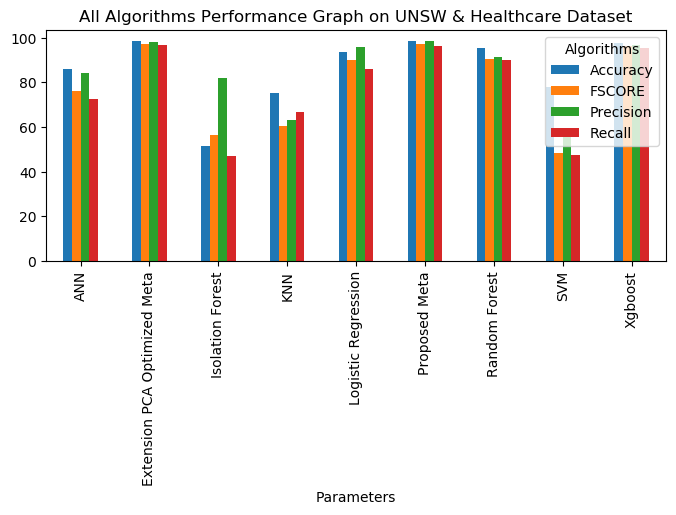

In [145]:
#plot all algorithm performance in graph format
df = pd.DataFrame([['Xgboost','Accuracy',accuracy[1]],['Xgboost','Precision',precision[1]],['Xgboost','Recall',recall[1]],['Xgboost','FSCORE',fscore[1]],
                   ['Random Forest','Accuracy',accuracy[3]],['Random Forest','Precision',precision[3]],['Random Forest','Recall',recall[3]],['Random Forest','FSCORE',fscore[3]],
                   ['Logistic Regression','Accuracy',accuracy[5]],['Logistic Regression','Precision',precision[5]],['Logistic Regression','Recall',recall[5]],['Logistic Regression','FSCORE',fscore[5]],
                   ['KNN','Accuracy',accuracy[7]],['KNN','Precision',precision[7]],['KNN','Recall',recall[7]],['KNN','FSCORE',fscore[7]],
                   ['Isolation Forest','Accuracy',accuracy[9]],['Isolation Forest','Precision',precision[9]],['Isolation Forest','Recall',recall[9]],['Isolation Forest','FSCORE',fscore[9]],
                   ['ANN','Accuracy',accuracy[11]],['ANN','Precision',precision[11]],['ANN','Recall',recall[11]],['ANN','FSCORE',fscore[11]],
                   ['SVM','Accuracy',accuracy[13]],['SVM','Precision',precision[13]],['SVM','Recall',recall[13]],['SVM','FSCORE',fscore[13]],
                   ['Proposed Meta','Accuracy',accuracy[15]],['Proposed Meta','Precision',precision[15]],['Proposed Meta','Recall',recall[15]],['Proposed Meta','FSCORE',fscore[15]],
                   ['Extension PCA Optimized Meta','Accuracy',accuracy[16]],['Extension PCA Optimized Meta','Precision',precision[16]],['Extension PCA Optimized Meta','Recall',recall[16]],['Extension PCA Optimized Meta','FSCORE',fscore[16]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph on UNSW & Healthcare Dataset")
plt.show()

In [146]:
#display all algorithm performnace
algorithms = ['XGBoost UNSW', 'XGBoost Healthcare', 'Random Forest UNSW', 'Random Forest Healthcare',
              'Logistic Regression UNSW', 'Logistic Regression Healthcare', 'KNN UNSW', 'KNN Healthcare',
              'Isolation Forest UNSW', 'Isolation Forest Healthcare', 'ANN UNSW', 'ANN Healthcare', 'SVM UNSW',
              'SVM Healthcare', 'Proposed Meta Model UNSW', 'Proposed Meta Model Healthcare', 
              'Extension PCA Optimized Meta UNSW & Healthcare']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,XGBoost UNSW,91.990632,83.001976,81.709253,82.168366
1,XGBoost Healthcare,97.798595,96.919208,95.534608,96.183086
2,Random Forest UNSW,92.224824,82.037349,78.948597,80.034639
3,Random Forest Healthcare,95.362998,91.233350,90.000769,90.341827
4,Logistic Regression UNSW,76.299766,58.749140,49.845457,50.220591
5,Logistic Regression Healthcare,93.676815,95.892754,85.870505,90.075269
6,KNN UNSW,85.995316,79.363663,71.046562,69.845255
7,KNN Healthcare,75.316159,63.329544,66.764148,60.613266
8,Isolation Forest UNSW,56.487119,82.457386,53.313618,60.279943
9,Isolation Forest Healthcare,51.615925,82.175926,46.940629,56.439853


In [147]:
#read both unsw and healthcare test data values
unsw_dataset = pd.read_csv(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\Dataset/unsw_test.csv", usecols=['sttl', 'synack', 'ct_dst_sport_ltm', 'ct_srv_dst', 'ct_srv_src', 'dbytes', 'smean', 'ct_dst_src_ltm',
                                                        'ct_src_dport_ltm', 'ct_state_ttl']) #load Unsw dataset
health_dataset = pd.read_csv(r"C:\Users\kotab\PycharmProjects\AnomlyDetection\.venv\IOMTHealthCare\Dataset/healthcare_test.csv")#load health data
unsw_dataset.fillna(dataset.mean(), inplace = True)
health_dataset.fillna(health_dataset.mean(), inplace = True)#replace misisng values with mean
unsw_dataset = unsw_dataset.values
unsw_dataset = scaler.fit_transform(unsw_dataset)#normalize both unsw and health data
health_dataset = health_dataset.values
health_dataset = health_scaler.fit_transform(health_dataset)
testData = np.hstack((unsw_dataset, health_dataset)) #add unsw features to health data
predict = extension_model.predict(testData)#apply extension model to predict attack type
for i in range(len(predict)):
    print("Test Data = "+str(testData[i])+" Predicted Attack Anomaly Type ====> "+labels[predict[i]])
    print()

Test Data = [-0.33333333 -3.         -0.33333333  0.01310153 -0.44962547 -2.65495395
 -0.3506581  -0.31642315 -0.41071765 -0.39570649  0.         -0.81649658
 -0.5         0.          0.47664128 -0.65465367  0.         -0.33333333
  0.65465367  0.5         0.         -0.33333333  0.          0.
 -0.77777778 -0.74478352 -0.55848937 -0.33333333 -1.         -0.66208471
  0.75        0.8046798 ] Predicted Attack Anomaly Type ====> Normal

Test Data = [ 3.          0.33333333  3.         -0.81666202 -0.94920932 -1.09321633
 -0.60112817 -1.0195857  -0.60174912 -0.84537297  0.         -0.81649658
 -0.5         0.         -1.02854171  1.52752523  0.         -0.33333333
  0.65465367  0.5         0.         -0.33333333  0.          0.
  0.33333333  0.78859432 -0.19425717 -0.33333333  1.          0.57932412
  0.75        0.8046798 ] Predicted Attack Anomaly Type ====> Worms

Test Data = [-0.33333333  0.33333333 -0.33333333 -0.3362726   0.88259814  0.46852129
  0.02504701  0.73832068 -0.12417045  